In [1]:
# Import other libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

# Options for plots
plt.rcParams['figure.figsize'] = (10, 6)
sbs.set('paper')

# Import litstudy
path = os.path.abspath(os.path.join('..'))
if path not in sys.path:
    sys.path.append(path)

!pip install litstudy
import litstudy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 72.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 74.3 MB/s  0:00:00
  Created wheel for litstudy: filename=litstudy-1.0.6-py3-none-any.whl size=50058 sha256=9e8bae0cfbd1755b7d78b9edf4d1e10b0c5704a71be702de372f7d296d5f4bbb
  Stored in directory: /home/yanx2/.cache/pip/wheels/72/97/1c/6327aca77228b1caa79d1c9070cd12d29924baa63498b167d8
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43688 sha256=1c7475c3e3501342347aecf0563b98d92ecd7b714c15459c297db8d7d4b11193


In [95]:
# Loading CSV file
docs_hea = litstudy.load_csv('HEA_Classification_78_8--.csv')
print(len(docs_hea), 'HEA papers loaded from CSV')

# Splitting docs according to the label
docs_ai = docs_hea.filter_docs(lambda d: d.language == 'AI')
print(len(docs_ai), 'AI related HEA papers')
docs_nai = docs_hea.filter_docs(lambda d: d.language != 'AI')
print(len(docs_nai), 'non-AI related HEA papers')
n = len(docs_nai)

842 HEA papers loaded from CSV
78 AI related HEA papers
764 non-AI related HEA papers


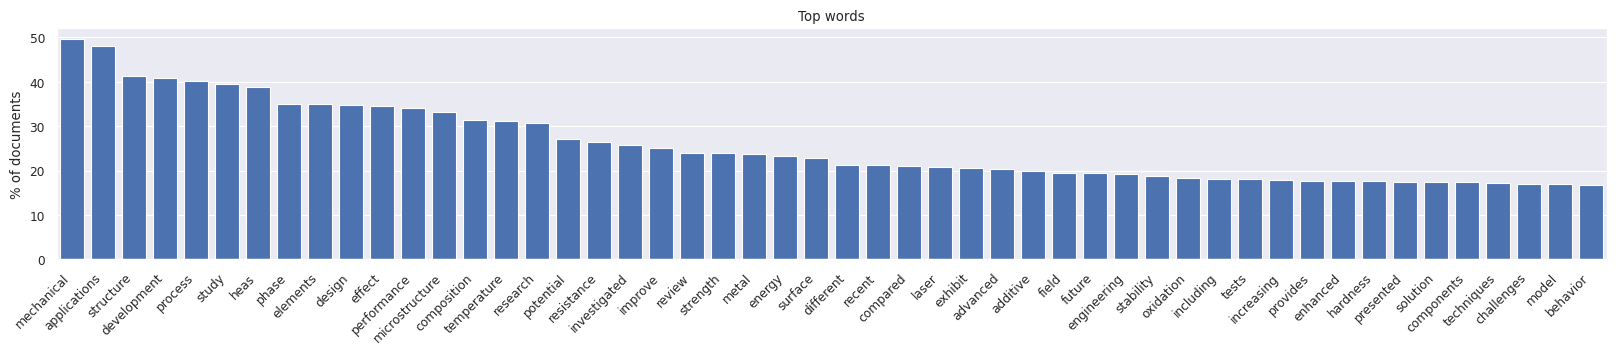

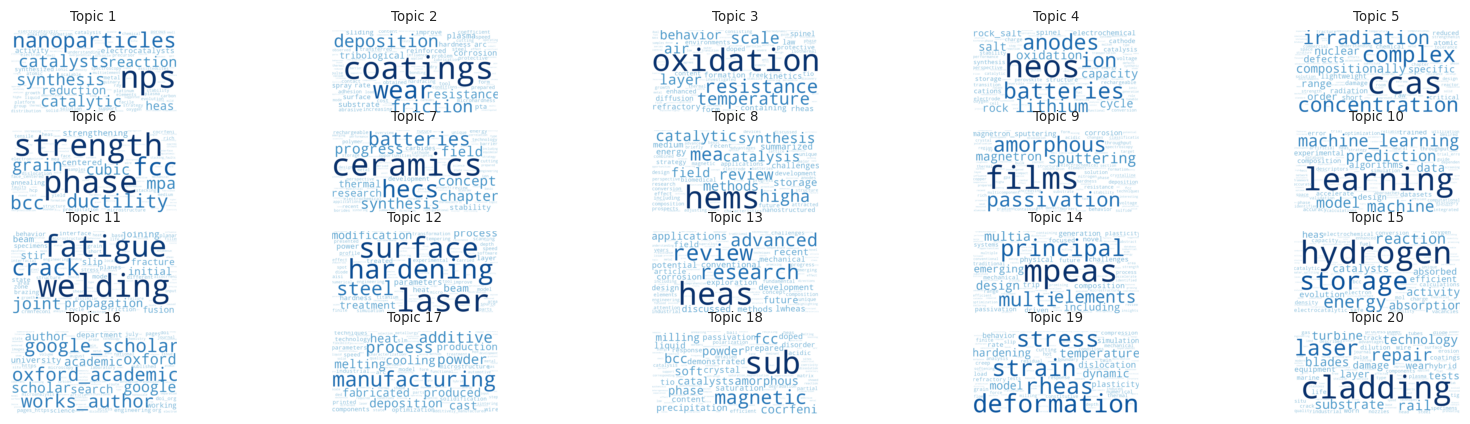

In [96]:
# topic modelling with 15 topics and plotting results
corpus = litstudy.build_corpus(docs_hea, ngram_threshold=0.9)
plt.figure(figsize=(20,3))
litstudy.plot_word_distribution(corpus,limit=50,title="Top words", vertical=True, label_rotation=45);
num_topics=20
topic_model = litstudy.train_nmf_model(corpus,num_topics,max_iter=250)
plt.figure(figsize=(20,5))
litstudy.plot_topic_clouds(topic_model,ncols=5);

In [97]:
# verify the titles of selected topic
ML_topic = topic_model.best_topic_for_token('machine_learning')
for doc_id in topic_model.best_documents_for_topic(ML_topic, limit=10):
    print(docs_hea[int(doc_id)].title)

Machine learning-enabled framework for the prediction of mechanical properties in new high entropy alloys
Sensitivity of short-range order prediction to machine learning potential formalisms: A case study on NbMoTaW high-entropy alloy
Enhancing flow stress predictions in CoCrFeNiV high entropy alloy with conventional and machine learning techniques
High-throughput data-driven machine learning prediction of thermal expansion coefficients of high-entropy solid solution carbides
Design, Performance Optimization and Application of High-Entropy Alloy Materials in Mechanical Engineering: A Review
Accelerated discovery of single-phase refractory high entropy alloys assisted by machine learning
Phase Prediction of High-Entropy Alloys by Integrating Criterion and Machine Learning Recommendation Method
Search for eutectic high entropy alloys by integrating high-throughput CALPHAD, machine learning and experiments
Modelling and prediction of hardness in multi-component alloys: A combined machine 

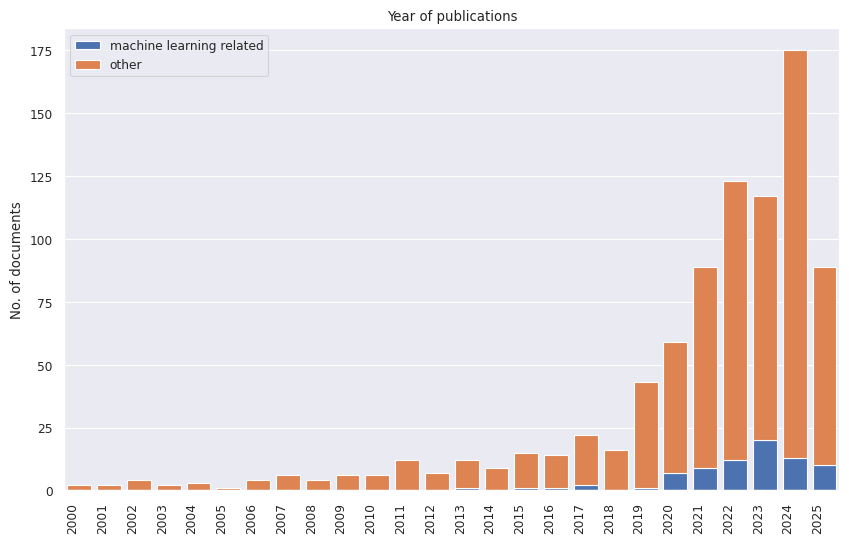

In [98]:
threshold = 0.2
ml_topic = topic_model.doc2topic[:, ML_topic] > threshold

docs_hea = docs_hea.add_property('ml_topic', ml_topic)

groups = {
    'machine learning related': 'ml_topic',
    'other': 'not ml_topic',
}

litstudy.plot_year_histogram(docs_hea, groups=groups, stacked=True, vertical = True);

In [99]:
# splitting the documents into ai & non-ai
indices_ai = [i for i, val in enumerate(ml_topic) if val == True ]
indices_nai = [i for i, val in enumerate(ml_topic) if val == False ]
print(len(indices_ai), 'AI related HEA papers')
print(len(indices_nai), 'non-AI related HEA papers')

docs_m_ai = docs_hea.select(indices_ai)
docs_m_nai = docs_hea.select(indices_nai)
print(docs_m_ai)
print(docs_m_nai)

77 AI related HEA papers
765 non-AI related HEA papers
<77 documents>
<765 documents>


In [100]:
docs_intersect = docs_ai.intersect(docs_m_ai)
print(docs_intersect)
# True Positive
tp = len(docs_intersect)

docs_diff = docs_ai.difference(docs_m_ai)
print(docs_diff)
# False Negative
fn = len(docs_diff)

docs_diff_1 = docs_m_ai.difference(docs_ai)
print(docs_diff_1)
# False Positive
fp = len(docs_diff_1)
for i in docs_diff_1:
    print(i.title)

# True Negative
tn = n - fp

<63 documents>
<15 documents>
<14 documents>
Unravelling Composition “Activity“ Stability Trends in High Entropy Alloy Electrocatalysts by Using a DataGuided Combinatorial Synthesis Strategy and Computational Modeling
Designing strategies and enhancing mechanism for multicomponent high-entropy catalysts
Automation of diffusion database development in multicomponent alloys from large number of experimental composition profiles
Elemental partitioning as a route to design precipitation-hardened high entropy alloys
Ball milling process variables optimization for high-entropy alloy development using design of experiment and genetic algorithm
Simulation and Modeling in High Entropy Alloys
Grouping strategy <i>via</i> d-orbit energy level to design eutectic high-entropy alloys
Electrical Equivalent Circuit Model Prediction of High-Entropy Alloy Behavior in Aggressive Media
Minimum cutting thickness prediction model for micro-milling machining and experimental Study of FeCoNiCrMn high-entropy

Accuracy: 0.9655581947743468
Precision: 0.8181818181818182
Recall: 0.8076923076923077
F1-score: 0.8129032258064518


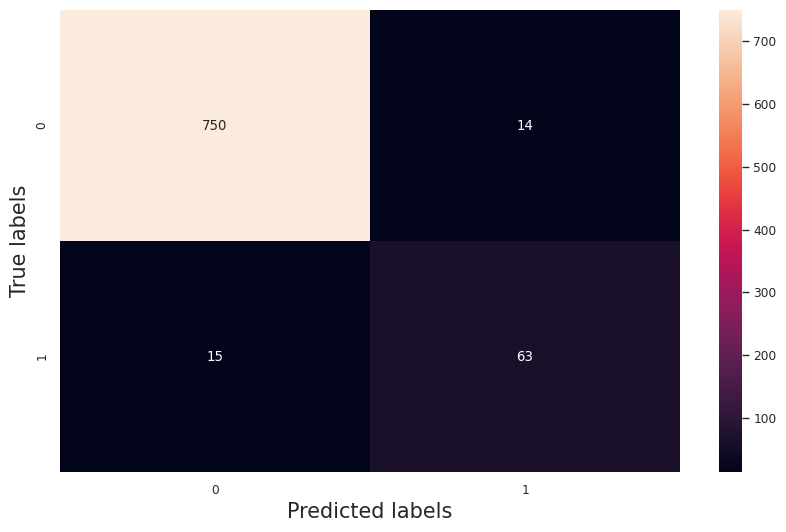

In [101]:

confmat = [[tn,fp],[fn,tp]]
acc = (tn+tp)/(tn+fp+fn+tp)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2*precision*recall/(precision+recall)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# plot the confusion matrix
ax = plt.subplot()
sbs.heatmap(confmat,annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted labels',fontsize=15)
ax.set_ylabel('True labels',fontsize=15)
plt.show()